# Lab 1: Interactive Image Mosaic Generator
把一张图切成小格子, 每个格子分个类, 再用对应的小 tile 换掉, 拼成马赛克。


## Assignment

Your task is to create an interactive image mosaic generator. Your app should reconstruct an input image using small tiles (mini-images). Each tile can be generated procedurally (using simple patterns) or selected from a set of available tiles. You should use Gradio to build the app. Here are some tips, steps and ideas to get you started.

**Some tips for using Gradio:**

When testing your Gradio app locally at http://localhost:7860, use the command `gradio app.py` instead of `python app.py` in the terminal. This will automatically refresh the app as you make changes.

You can use the examples parameter in `gr.Interface(...)` to provide sample inputs (e.g., testing images). These examples will appear below the UI components and can be clicked to populate the interface, making it faster to test your app without manually uploading or dragging files.

You can create a temporary 3-day web link for your Gradio app. For a more permanent link, you can deploy it for free on Hugging Face Spaces. Please do not use the 3-day web link and, instead, use Hugging Face Spaces. Using Hugging Face Spaces is similar to using GitHub. For more details, visit: https://www.gradio.app/guides/sharing-your-app and https://huggingface.co/blog/gradio-spaces

If you deploy on Hugging Face Spaces, it's recommended to include specific library versions in the requirements.txt file (e.g., opencv-python==4.9.0.80) to ensure consistent results, as versions may differ from what's used locally with the Gradio server.

**Step 1: Image Selection and Preprocessing**
Select a test image (you may slightly crop the image if needed to fit a grid). Convert the image into a 3-channel (RGB) image if it isn't already.

**Step 2: Image Grid and Thresholding**
Divide the image into a grid of fixed-size blocks. Analyze the colors in each block, and classify each block into a color category. Use vectorized operations to efficiently handle pixel data and avoid explicit loops.

**Step 3: Tile Mapping**
Prepare a set of small tiles, where each tile corresponds to a color category. Replace each block of the original image with the corresponding tile to create the mosaic.

**Step 4: Gradio Interface**
Use Gradio to create an interactive interface where the user can upload an image and see the resulting mosaic in real time.

**Step 5: Performance Metric**
Incorporate similarity metrics (e.g., MSE, SSIM) to compare the original image with the mosaic version.

**Step 6: Performance Analysis**
Conduct a performance analysis to assess the time efficiency of your implementation. Compare your implementation's performance on different grid sizes.

**Creative Component:**
To enhance your app and earn extra credit, consider adding a creative component. For example, you can use different types of tiles (e.g., patterns, emojis, text) or allow users to customize the tile size and color mapping.

**Deliverables:**
1. A Jupyter Notebook (.ipynb) file that demonstrates each step of your project.
2. A short report (1-2 pages) that includes:
- A description of your app
- The results of your analysis
- Reflections on what you learned
3. A Gradio app deployed on Hugging Face Spaces with a public URL. You'll be graded based on how well your app works and looks.

In [ ]:
!pip install -q scikit-image  # 算 SSIM 要用, 装一下

## Step 1: 选图 + 预处理
三件事: 读图 → 转成 0~255 的整数 RGB → 裁成格子大小的整数倍。

In [29]:
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [30]:
def get_time(f):
    # 计时小工具: 套在函数外面, 跑完会打印花了多少微秒
    def inner(*arg, **kwarg):
        s = time.perf_counter_ns()
        res = f(*arg, **kwarg)
        e = time.perf_counter_ns()
        used_us = (e - s) / 1e3
        print(f.__name__, "took", round(used_us, 1), "us")
        return res
    return inner

shape: (350, 350, 3)
dtype: float32
min: 0.0
max: 1.0


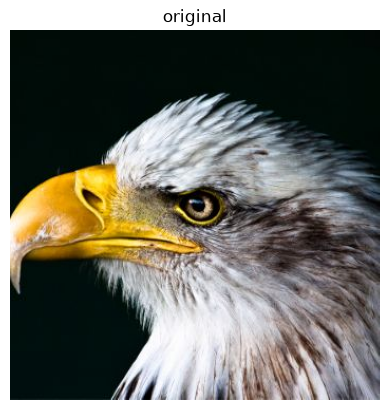

In [31]:
# 把测试图读进来, notebook 和 image.png 放同一个文件夹就行
img_raw = plt.imread('image.png')

# 先看看读进来的是个啥
print("shape:", img_raw.shape)
print("dtype:", img_raw.dtype)
print("min:", img_raw.min())
print("max:", img_raw.max())

# 显示原图看一眼
plt.imshow(img_raw)
plt.axis('off')
plt.title('original')
plt.show()

# 小知识: plt.imread 读 PNG 得到的是 0~1 之间的小数
# 但我们的调色板是 0~255 的整数, 算距离之前得先统一量纲
# 不然所有像素都会被判成黑色, 分类就全错了

In [32]:
def to_uint8_rgb(img):
    # 转成 uint8 的 RGB: 透明通道扔掉, 小数转成整数
    img = np.asarray(img)

    if img.shape[-1] == 4:
        img = img[..., :3]

    if img.dtype != np.uint8:
        img = (np.clip(img, 0, 1) * 255).round().astype(np.uint8)

    return np.ascontiguousarray(img)


def crop_to_grid(img, p):
    # 从中间裁一刀, 让高和宽都变成 p 的整数倍
    # 比如 350 裁成 320 (p=32 时), 作业说轻微裁剪是可以的
    h, w = img.shape[:2]
    h2 = (h // p) * p
    w2 = (w // p) * p
    y0 = (h - h2) // 2
    x0 = (w - w2) // 2
    return np.ascontiguousarray(img[y0:y0 + h2, x0:x0 + w2])


def preprocess(img, grid_size):
    # Step 1: 转格式, 再裁剪
    img = to_uint8_rgb(img)
    img = crop_to_grid(img, grid_size)
    return img


after shape: (320, 320, 3)
after type: uint8


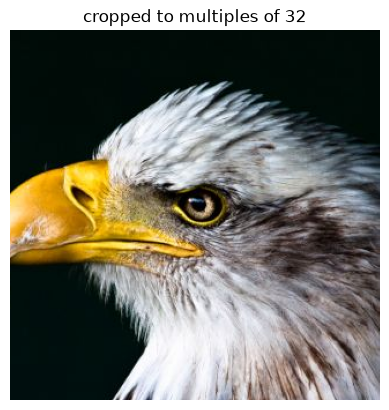

In [33]:
GRID = 32

img = preprocess(img_raw, GRID)

print("after shape:", img.shape)
print("after type:", img.dtype)

plt.imshow(img)
plt.axis('off')
plt.title("cropped to multiples of 32")
plt.show()


## Step 2: 切网格 + 分类
把图切成小格子, 算每个格子的平均颜色, 再分到最近的调色板颜色。
作业要求: 用向量化的 NumPy, 别写嵌套循环。

In [ ]:
def patches_pure_python(img, p):
    # 纯 Python 版切块: 只用嵌套循环, 不用 numpy
    # 思路分两步: 先把图片"翻译"成普通嵌套列表, 再一块一块抠出来
    h = len(img)
    w = len(img[0])

    # 第一步: 图片 -> 嵌套列表, img_list[行][列] = [r, g, b]
    img_list = []
    for y in range(h):
        row = []
        for x in range(w):
            r = int(img[y][x][0])
            g = int(img[y][x][1])
            b = int(img[y][x][2])
            row.append([r, g, b])
        img_list.append(row)

    # 第二步: 按块取, 一块是 p x p 个像素
    gy = h // p
    gx = w // p

    patches = []
    for by in range(gy):            # 块在第几行
        for bx in range(gx):        # 块在第几列
            patch = []
            for dy in range(p):     # 块里面的第几行
                prow = []
                for dx in range(p):  # 块里面的第几列
                    y = by * p + dy
                    x = bx * p + dx
                    prow.append(img_list[y][x])
                patch.append(prow)
            patches.append(patch)

    return patches

patches_pure_python took 86100.7 us
num patches: 100
rows per patch: 32
pixels per row: 32
channels per pixel: 3


In [35]:
@get_time
def patches_loop(img, p):
    # 循环版切块: 一块一块取出来, 存进一个大数组
    # 注意 return 的位置! 必须和外层 for 对齐
    # 如果缩进多了一格, 就只会返回第一行的块, 后面全是黑的
    h, w, c = img.shape
    gy = h // p
    gx = w // p
    res = np.zeros((gy * gx, p, p, c), dtype=img.dtype)

    idx = 0
    for y in range(gy):
        for x in range(gx):
            res[idx] = img[y*p:(y+1)*p, x*p:(x+1)*p]
            idx = idx + 1

    return res


patches = patches_loop(img, GRID)
print("num patches:", patches.shape[0])
print("patch shape:", patches.shape[1:])


patches_loop took 743.7 us
num patches: 100
patch shape: (32, 32, 3)


In [36]:

@get_time
def cell_means_loop(img, p):
    # 循环版: 一块一块算平均颜色, 慢, 只用来跟向量化版对比
    patches = patches_loop(img, p)
    gy = img.shape[0] // p
    gx = img.shape[1] // p
    means = patches.reshape(-1, p * p, 3).mean(axis=1)
    return means.reshape(gy, gx, 3)


@get_time
def cell_means_vec(img, p):
    # 向量化版: 不用循环, 一次 reshape 全算完
    # 思路: 把 (高, 宽, 3) 看成 (块行数, 块内行, 块列数, 块内列, 3)
    # 然后对两个块内维度求平均, 就得到每块的平均色了
    h, w = img.shape[:2]
    big = img.reshape(h // p, p, w // p, p, 3)
    return big.mean(axis=(1, 3))


print("--- loop version ---")
m_loop = cell_means_loop(img, GRID)

print("--- vectorized version ---")
m_vec = cell_means_vec(img, GRID)

print("loop result shape:", m_loop.shape)
print("vectorized result shape:", m_vec.shape)
print("results identical:", np.allclose(m_loop, m_vec))


--- loop version ---
patches_loop took 743.6 us
cell_means_loop took 1775.4 us
--- vectorized version ---
cell_means_vec took 1055.9 us
loop result shape: (10, 10, 3)
vectorized result shape: (10, 10, 3)
results identical: True


cell_means_vec took 1289.0 us
category map shape: (10, 10)
patches per color:
   red : 2
   green : 0
   blue : 1
   yellow : 11
   black : 56
   white : 30


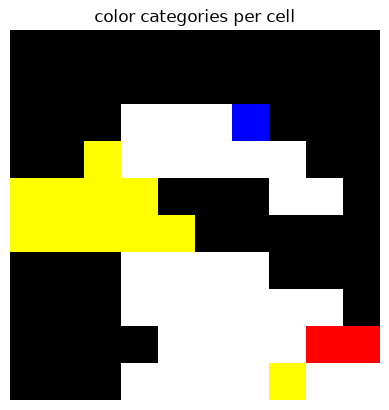

In [37]:
# 6 个颜色的调色板
PALETTE = np.array([
    [255, 0, 0],      # 红
    [0, 255, 0],      # 绿
    [0, 0, 255],      # 蓝
    [255, 255, 0],    # 黄
    [0, 0, 0],        # 黑
    [255, 255, 255],  # 白
], dtype=np.uint8)
PALETTE_NAMES = ['red', 'green', 'blue', 'yellow', 'black', 'white']


def classify_cells(cells):
    # 每个格子找离它最近的调色板颜色
    # 用广播一次算完所有格子到 6 个颜色的距离, 不用循环
    diff = cells[..., None, :].astype(np.float64) - PALETTE.astype(np.float64)
    dists = np.linalg.norm(diff, axis=-1)
    return np.argmin(dists, axis=-1)


cells = cell_means_vec(img, GRID)
cat = classify_cells(cells)

print("category map shape:", cat.shape)
print("patches per color:")
for i, name in enumerate(PALETTE_NAMES):
    count = int((cat == i).sum())
    print("  ", name, ":", count)

# 把分类结果画出来看看
plt.imshow(PALETTE[cat])
plt.axis('off')
plt.title('color categories per cell')
plt.show()


## Step 3: 把格子换成 tile
准备 tile, 按分类结果把每个格子替换掉, 拼出马赛克。

In [38]:
def make_pattern_bank(t=32):
    # 现场生成 7 种 tile 图案
    solid = np.ones((t, t))                                    # 纯色
    h_grad = np.tile(np.linspace(0.5, 1.0, t), (t, 1))         # 横向渐变
    v_grad = np.tile(np.linspace(0.5, 1.0, t)[:, None], (1, t))  # 纵向渐变

    yy, xx = np.mgrid[0:t, 0:t].astype(float)
    checker = ((xx // (t // 4) + yy // (t // 4)) % 2) * 0.5 + 0.5   # 棋盘格
    v_stripes = 0.75 + 0.25 * np.sin(2 * np.pi * xx / t * 3)        # 竖条纹
    d_stripes = 0.75 + 0.25 * np.sin(2 * np.pi * (xx + yy) / t * 2) # 斜条纹

    cx = (t - 1) / 2
    cy = (t - 1) / 2
    r = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2) / (np.sqrt(2) * (t - 1) / 2)
    radial = 1.0 - 0.5 * r                                        # 放射渐变

    # 每个图案都除以自己的均值, 让平均亮度变成 1
    # 这样图案乘以格子平均色之后, tile 的平均亮度就跟原格子差不多了
    pats = [solid, h_grad, v_grad, checker, v_stripes, d_stripes, radial]
    bank = []
    for p in pats:
        bank.append(np.clip(p / p.mean(), 0, 1.5))
    return bank


def build_mosaic(img, grid_size=32, tile_style='solid'):
    # 主函数: 输入原图, 输出马赛克
    # tile_style 有三种:
    #   'solid'   -> 每个格子填调色板颜色 (6 色海报风)
    #   'smooth'  -> 每个格子填自己的平均色 (最像原图)
    #   'pattern' -> 每个格子贴图案 tile, 再按平均色染色 (创意)
    img = preprocess(img, grid_size)
    cells = cell_means_vec(img, grid_size)
    gy = cells.shape[0]
    gx = cells.shape[1]
    p = grid_size

    if tile_style == 'smooth':
        mosaic = np.repeat(np.repeat(cells, p, axis=0), p, axis=1)

    elif tile_style == 'solid':
        cat = classify_cells(cells)
        colors = PALETTE[cat]
        mosaic = np.repeat(np.repeat(colors, p, axis=0), p, axis=1)

    elif tile_style == 'pattern':
        bank = np.stack(make_pattern_bank(p))
        cat = classify_cells(cells)
        sel = bank[cat % len(bank)]
        tinted = sel[..., None] * cells[:, :, None, None, :]
        mosaic = tinted.transpose(0, 2, 1, 3, 4).reshape(gy * p, gx * p, 3)

    else:
        raise ValueError("tile_style 只能是 solid / smooth / pattern")

    mosaic = np.clip(mosaic, 0, 255).astype(np.uint8)
    return mosaic, img


cell_means_vec took 666.4 us
cell_means_vec took 681.0 us
cell_means_vec took 990.9 us
base image shape: (320, 320, 3)
mosaic shape: (320, 320, 3)


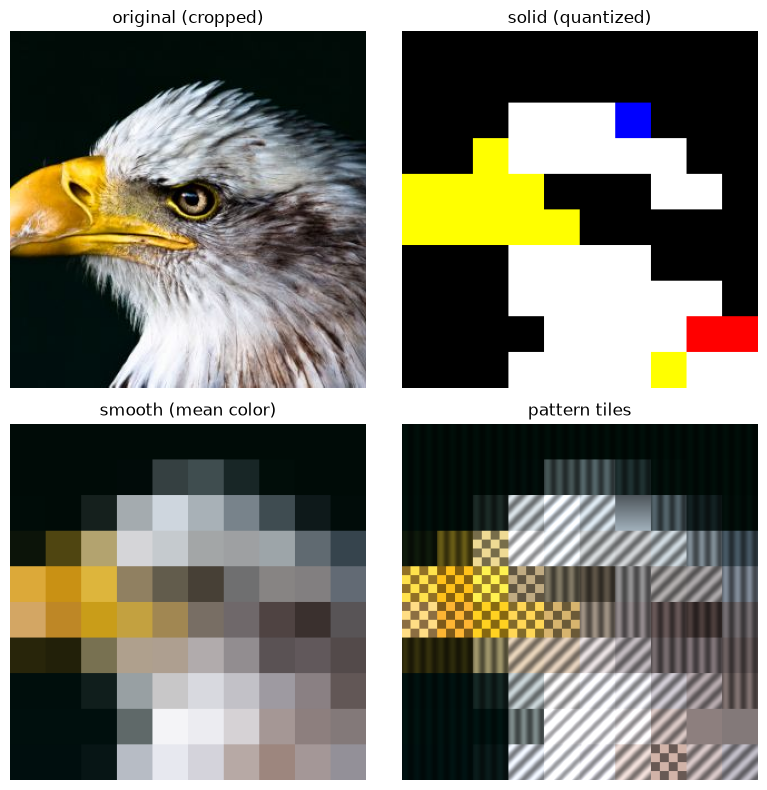

In [39]:
# 三种风格各生成一张
mosaic_solid, base = build_mosaic(img_raw, GRID, 'solid')
mosaic_smooth, _ = build_mosaic(img_raw, GRID, 'smooth')
mosaic_pattern, _ = build_mosaic(img_raw, GRID, 'pattern')

print("base image shape:", base.shape)
print("mosaic shape:", mosaic_solid.shape)

# 四张图摆在一起看
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0, 0].imshow(base)
axes[0, 0].set_title('original (cropped)')

axes[0, 1].imshow(mosaic_solid)
axes[0, 1].set_title('solid (quantized)')

axes[1, 0].imshow(mosaic_smooth)
axes[1, 0].set_title('smooth (mean color)')

axes[1, 1].imshow(mosaic_pattern)
axes[1, 1].set_title('pattern tiles')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()


## Step 4: Gradio 界面
界面在独立文件 **`app.py`** 里, 这里不放。

作业里的 tip 都已经照做了:
- 本地跑用 `gradio app.py`, 别用 `python app.py`, 改代码会自动刷新
- `app.py` 里加了 `gr.Examples`, 界面下方点一下 `image.png` 就能直接测, 不用手动上传
- 部署用 Hugging Face Spaces 拿永久链接, 别用 3 天临时链接
- `requirements.txt` 里锁了版本号, 保证 Spaces 上的环境跟本地一致

## Step 5: 算相似度
MSE 越小越好, SSIM 越接近 1 越好。

In [ ]:
def mse(a, b):
    # MSE: 两张图逐像素作差, 平方, 再平均
    # 0 表示一模一样, 越小越好
    diff = a.astype(np.float64) - b.astype(np.float64)
    return float(np.mean(diff ** 2))


def ssim_index(a, b):
    # SSIM: 综合看亮度、对比度、结构, 越接近 1 越好, 更符合人眼感受
    from skimage.metrics import structural_similarity
    return float(structural_similarity(a, b, channel_axis=2, data_range=255))


print("solid MSE:", round(mse(base, mosaic_solid), 2))
print("solid SSIM:", round(ssim_index(base, mosaic_solid), 4))
print()
print("smooth MSE:", round(mse(base, mosaic_smooth), 2))
print("smooth SSIM:", round(ssim_index(base, mosaic_smooth), 4))
print()
print("pattern MSE:", round(mse(base, mosaic_pattern), 2))
print("pattern SSIM:", round(ssim_index(base, mosaic_pattern), 4))



solid MSE: 6601.49
solid SSIM: 0.2014

smooth MSE: 1649.77
smooth SSIM: 0.3884

pattern MSE: 2448.58
pattern SSIM: 0.2968


## Step 6: 测速度
看看不同格子大小要跑多久, 再对比循环版和向量化版。

In [ ]:
timed_build = get_time(build_mosaic)

print("timing for different grid sizes:")
print()
for g in [16, 32, 64]:
    print("grid_size =", g)
    timed_build(img_raw, g, 'solid')
    print()

print("loop vs vectorized (grid_size=32):")
print()
cell_means_loop(img, GRID)
print()
cell_means_vec(img, GRID)



timing for different grid sizes:

grid_size = 16
cell_means_vec took 1289.8 us
build_mosaic took 2676.4 us

grid_size = 32
cell_means_vec took 934.3 us
build_mosaic took 2333.6 us

grid_size = 64
cell_means_vec took 805.1 us
build_mosaic took 1986.4 us

loop vs vectorized (grid_size=32):

patches_loop took 58.3 us
cell_means_loop took 807.0 us

cell_means_vec took 1002.3 us


array([[[2.49023438e-01, 1.18818359e+01, 7.87988281e+00],
        [1.80664062e-01, 1.12031250e+01, 7.20312500e+00],
        [3.13476562e-01, 1.13134766e+01, 7.31347656e+00],
        [1.47460938e-01, 1.13046875e+01, 7.30468750e+00],
        [4.14062500e-01, 1.14208984e+01, 7.42089844e+00],
        [9.17968750e-02, 1.10537109e+01, 7.05371094e+00],
        [4.39453125e-01, 1.14384766e+01, 7.40917969e+00],
        [1.95312500e-01, 1.13671875e+01, 7.36523438e+00],
        [3.12500000e-01, 1.14853516e+01, 7.45410156e+00],
        [3.00781250e-01, 1.12861328e+01, 7.26953125e+00]],

       [[2.24609375e-02, 1.18203125e+01, 7.82031250e+00],
        [8.59375000e-02, 1.11015625e+01, 7.10156250e+00],
        [3.63281250e-01, 1.13632812e+01, 7.36328125e+00],
        [1.42480469e+00, 1.18242188e+01, 9.33886719e+00],
        [5.32792969e+01, 6.48779297e+01, 6.53378906e+01],
        [6.39892578e+01, 7.72382812e+01, 7.98916016e+01],
        [2.43691406e+01, 3.82246094e+01, 3.82294922e+01],
        [1.6